# Регрессия для SI

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor

In [23]:
PROJECT_ROOT = Path.cwd().parents[1]
CSV_PATH = PROJECT_ROOT / Path("./data/reg_si.csv").resolve()
print(CSV_PATH)

E:\Study\projects\coursework_classic_ml\data\reg_si.csv


In [24]:
df = pd.read_csv(CSV_PATH)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,target
0,-1.609209,1.315234,1.274257,-0.900747,1.055290,0.0,1.389704,-1.566113,-2.076304,-0.731655,...,-0.110152,-0.09525,-0.031623,-0.031623,-0.234082,0.0,-0.274204,4.361269,-0.083918,28.125000
1,-1.733165,1.698809,1.616019,-0.717860,1.234754,0.0,1.184451,-1.782336,-2.224521,-0.708822,...,-0.110152,-0.09525,-0.031623,-0.031623,-0.234082,0.0,-0.274204,4.361269,-0.083918,7.000000
2,-1.831528,1.717840,1.639180,-1.432643,0.997105,0.0,1.053951,-1.099982,-2.409791,-0.653210,...,-0.110152,-0.09525,-0.031623,-0.031623,-0.234082,0.0,-0.274204,4.361269,-0.083918,0.720000
3,-1.608793,1.326268,1.281687,-1.049655,0.971554,0.0,1.389704,-1.566113,-2.168300,-0.731812,...,-0.110152,-0.09525,-0.031623,-0.031623,-0.234082,0.0,-0.274204,4.361269,-0.083918,63.235294
4,-1.601971,0.843212,1.030148,-0.854751,0.551671,0.0,1.739635,-1.365744,-2.254164,-0.730327,...,-0.110152,-0.09525,-0.031623,-0.031623,-0.234082,0.0,-0.274204,-0.229295,-0.083918,1.300000


In [25]:
X_ic50 = df.drop(columns=['target'])
y_ic50 = df['target']
X_train, X_test, y_train, y_test = train_test_split(X_ic50, y_ic50, test_size=0.1, random_state=42)

In [26]:
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 7, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': [0.5, 'sqrt', 'log2']
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train, y_train)
y_pred_train = grid_search_rf.best_estimator_.predict(X_train)
y_pred_test = grid_search_rf.best_estimator_.predict(X_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

retraining = abs(train_r2 - test_r2)

print(f"\n=== RandomForestRegressor производительность модели SI ===")
print(f"Обучение R2: {train_r2:.4f}")
print(f"Тест R2:  {test_r2:.4f}")
print(f"Обучение MSE: {train_mse:.4f}")
print(f"Тест MSE:  {test_mse:.4f}")
print(f"\nПоказатель переобучения: {retraining:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

=== RandomForestRegressor производительность модели SI ===
Обучение R2: 0.1296
Тест R2:  0.0734
Обучение MSE: 318566.3482
Тест MSE:  1272895.3346

Показатель переобучения: 0.0562


RandomForestRegressor низкая производительность модели, объясняет почти хуже чем среднее

<Axes: xlabel='importance', ylabel='feature'>

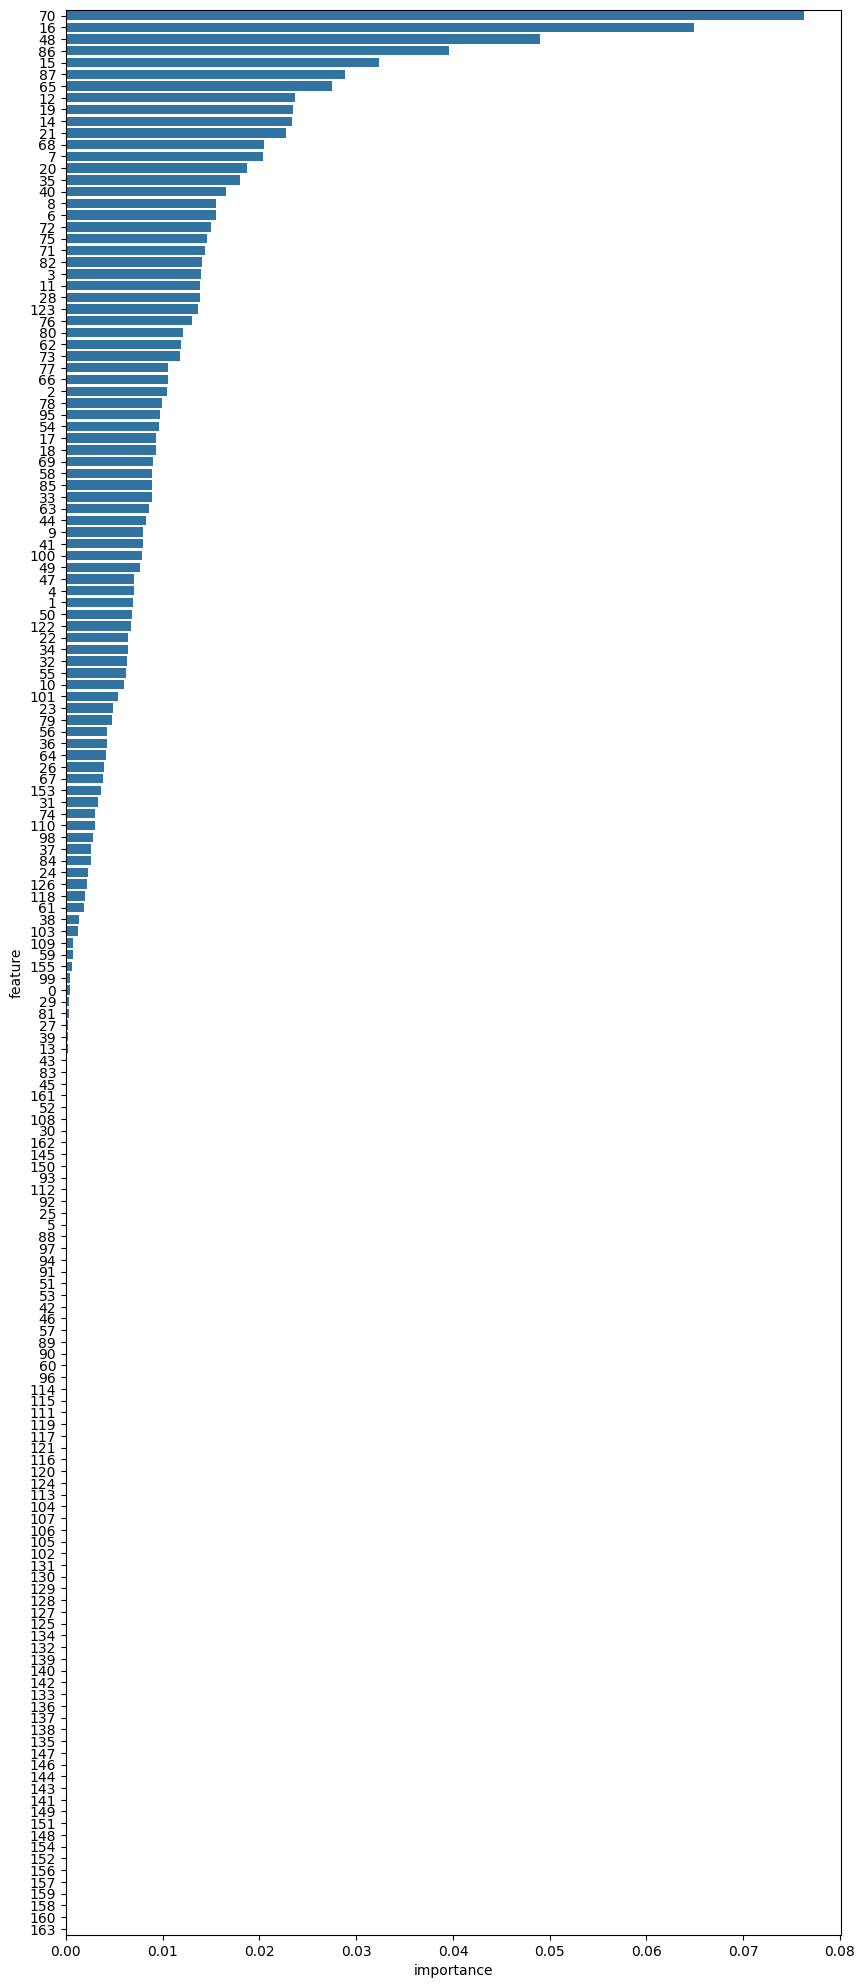

In [27]:
fi = grid_search_rf.best_estimator_.feature_importances_
df_fi = pd.DataFrame({'feature': X_ic50.columns, 'importance': fi})
df_fi = df_fi.sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 25))
sns.barplot(data=df_fi, x='importance', y='feature')

на графике показывает важность признаков, какие признаки дают больший вклад в объясненную дисперсию, а какие меньше. Но так как это медицинские данные нельзя просто признаки удалять

In [28]:
ridge = Ridge(random_state=42)
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search_ridge.fit(X_train, y_train)
y_pred_train_ridge = grid_search_ridge.best_estimator_.predict(X_train)
y_pred_test_ridge = grid_search_ridge.best_estimator_.predict(X_test)


train_r2_ridge = r2_score(y_train, y_pred_train_ridge)
test_r2_ridge = r2_score(y_test, y_pred_test_ridge)
train_mse_ridge = mean_squared_error(y_train, y_pred_train_ridge)
test_mse_ridge = mean_squared_error(y_test, y_pred_test_ridge)

retraining_ridge = abs(train_r2_ridge - test_r2_ridge)

print(f"\n=== Ridge производительность модели SI ===")
print(f"Обучение R2: {train_r2_ridge:.4f}")
print(f"Тест R2:  {test_r2_ridge:.4f}")
print(f"Обучение MSE: {train_mse_ridge:.4f}")
print(f"Тест MSE:  {test_mse_ridge:.4f}")
print(f"\nПоказатель переобучения: {retraining_ridge:.4f}")
print(f"\nЛучшие параметры: {grid_search_ridge.best_estimator_}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

=== Ridge производительность модели SI ===
Обучение R2: 0.1141
Тест R2:  0.1179
Обучение MSE: 324212.5944
Тест MSE:  1211766.4364

Показатель переобучения: 0.0037

Лучшие параметры: Ridge(alpha=100, random_state=42)


Ridge низкая производительность модели, объясняет почти хуже чем среднее

In [29]:
lasso = Lasso(random_state=42)
param_grid_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search_lasso.fit(X_train, y_train)
y_pred_train_lasso = grid_search_lasso.best_estimator_.predict(X_train)
y_pred_test_lasso = grid_search_lasso.best_estimator_.predict(X_test)


train_r2_lasso = r2_score(y_train, y_pred_train_lasso)
test_r2_lasso = r2_score(y_test, y_pred_test_lasso)
train_mse_lasso = mean_squared_error(y_train, y_pred_train_lasso)
test_mse_lasso = mean_squared_error(y_test, y_pred_test_lasso)

retraining_lasso = abs(train_r2_lasso - test_r2_lasso)

print(f"\n=== Lasso производительность модели SI ===")
print(f"Обучение R2: {train_r2_lasso:.4f}")
print(f"Тест R2:  {test_r2_lasso:.4f}")
print(f"Обучение MSE: {train_mse_lasso:.4f}")
print(f"Тест MSE:  {test_mse_lasso:.4f}")
print(f"\nПоказатель переобучения: {retraining_lasso:.4f}")
print(f"\nЛучшие параметры: {grid_search_lasso.best_estimator_}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

=== Lasso производительность модели SI ===
Обучение R2: 0.0000
Тест R2:  -0.0032
Обучение MSE: 365980.5378
Тест MSE:  1378003.4074

Показатель переобучения: 0.0032

Лучшие параметры: Lasso(alpha=100, random_state=42)


Lasso низкая производительность модели, объясняет хуже чем среднее

In [36]:
xgb = XGBRegressor(random_state = 42, device="cuda", tree_method="hist")
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1],
    'alpha': [0, 0.1, 1],
    'lambda': [1, 5, 10]
}
grid_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=1,
    verbose=1
)
grid_search_xgb.fit(X_train, y_train)


y_pred_train_xgb = grid_search_xgb.best_estimator_.predict(X_train)
y_pred_test_xgb = grid_search_xgb.best_estimator_.predict(X_test)

train_r2_xgb = r2_score(y_train, y_pred_train_xgb)
test_r2_xgb = r2_score(y_test, y_pred_test_xgb)
train_mse_xgb = mean_squared_error(y_train, y_pred_train_xgb)
test_mse_xgb = mean_squared_error(y_test, y_pred_test_xgb)

retraining_xgb = abs(train_r2_xgb - test_r2_xgb)

print(f"\n=== XGBRegressor производительность модели SI ===")
print(f"Обучение R2: {train_r2_xgb:.4f}")
print(f"Тест R2:  {test_r2_xgb:.4f}")
print(f"Обучение MSE: {train_mse_xgb:.4f}")
print(f"Тест MSE:  {test_mse_xgb:.4f}")
print(f"\nПоказатель переобучения: {retraining_xgb:.4f}")
print(f"\nЛучшие параметры: {grid_search_xgb.best_params_}")


Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== XGBRegressor производительность модели SI ===
Обучение R2: 0.1536
Тест R2:  0.1070
Обучение MSE: 309774.7984
Тест MSE:  1226679.6075

Показатель переобучения: 0.0466

Лучшие параметры: {'subsample': 1, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.01, 'lambda': 10, 'colsample_bytree': 0.7, 'alpha': 0.1}


Lasso низкая производительность модели, объясняет хуже чем среднее

In [31]:
df_metrics_train = pd.DataFrame({
    'Model': ['RandomForest', 'Ridge', 'Lasso', 'XGBoost'],
    'R2': [train_r2, train_r2_ridge, train_r2_lasso, train_r2_xgb],
    'MSE': [train_mse, train_mse_ridge, train_mse_lasso, train_mse_xgb]
})

df_metrics_test = pd.DataFrame({
    'Model': ['RandomForest', 'Ridge', 'Lasso', 'XGBoost'],
    'R2': [test_r2, test_r2_ridge, test_r2_lasso, test_r2_xgb],
    'MSE': [test_mse, test_mse_ridge, test_mse_lasso, test_mse_xgb],
    'RETRAINING': [retraining, retraining_ridge, retraining_lasso, retraining_xgb]
})

C:\Users\arayd\AppData\Local\Temp\ipykernel_6592\862235921.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


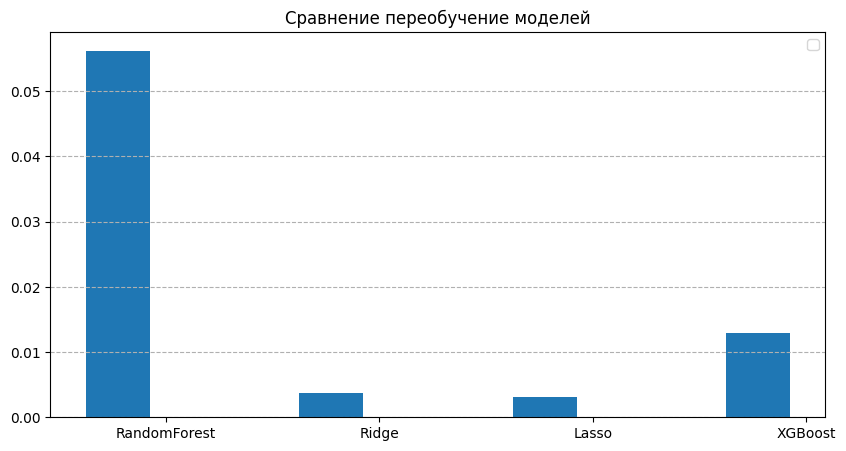

In [32]:
plt.figure(figsize=(10, 5))
width = 0.3
x = np.arange(len(df_metrics_test['Model']))
plt.bar(x - 0.75 * width, df_metrics_test['RETRAINING'], width)
plt.xticks(x, df_metrics_test['Model'])
plt.legend()
plt.grid(axis='y',linestyle= '--')
plt.title('Сравнение переобучение моделей')
plt.show()

у всех моделей кроме RandomForest, нет переобучения, но и RandomForest переобучения почти нет

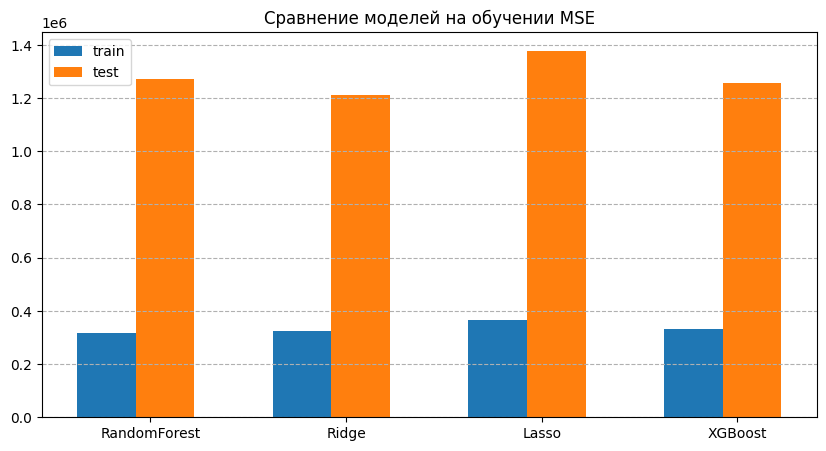

In [33]:
plt.figure(figsize=(10, 5))
width = 0.3
x = np.arange(len(df_metrics_train['Model']))
plt.bar(x - 0.75 * width, df_metrics_train['MSE'], width, label='train')
plt.bar(x + 0.25 * width, df_metrics_test['MSE'], width, label='test')
plt.xticks(x, df_metrics_train['Model'])
plt.legend()
plt.grid(axis='y',linestyle= '--')
plt.title('Сравнение моделей на обучении MSE')
plt.show()

очень высокий MSE так как есть выбросы, и плохо обучены модели

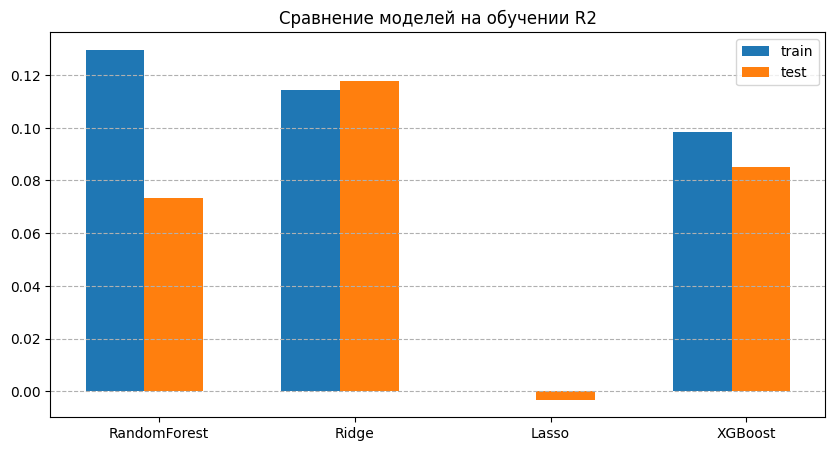

In [35]:
plt.figure(figsize=(10, 5))
width = 0.3
x = np.arange(len(df_metrics_train['Model']))
plt.bar(x - 0.75 * width, df_metrics_train['R2'], width, label='train')
plt.bar(x + 0.25 * width, df_metrics_test['R2'], width, label='test')
plt.xticks(x, df_metrics_train['Model'])
plt.legend()
plt.grid(axis='y',linestyle= '--')
plt.title('Сравнение моделей на обучении R2')
plt.show()

Вывод: Хуже всего показала модель линейная регрессия с L1-регуляризацией (Lasso), лучше всего линейная регрессия с L2-регуляризацией (Ridge), все модели показали не очень хорошие результаты.